In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/california_housing.csv")

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [3]:
# Check for missing values
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

In [4]:
# Statistical summary of numerical features
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


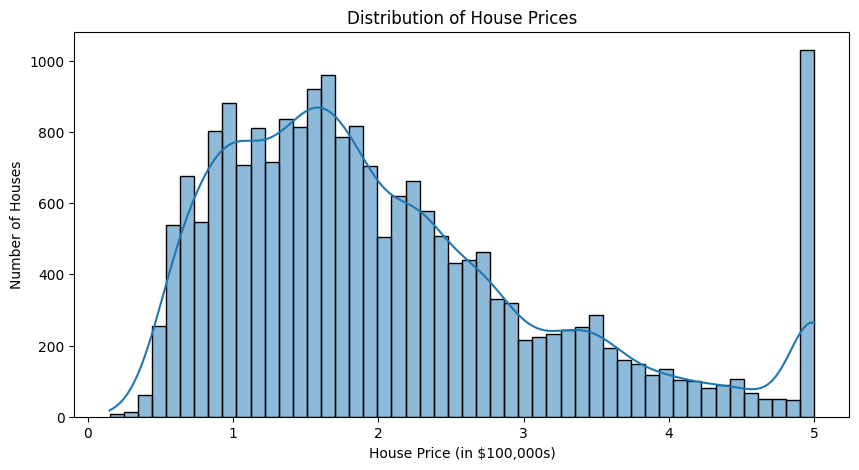

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.histplot(df["MedHouseVal"], bins=50, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("House Price (in $100,000s)")
plt.ylabel("Number of Houses")

plt.show()

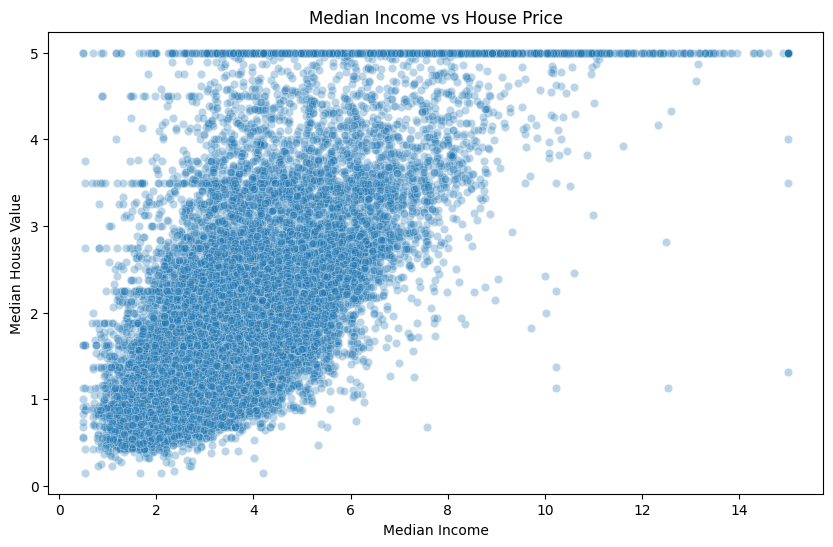

In [6]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Median Income vs House Price")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.show()

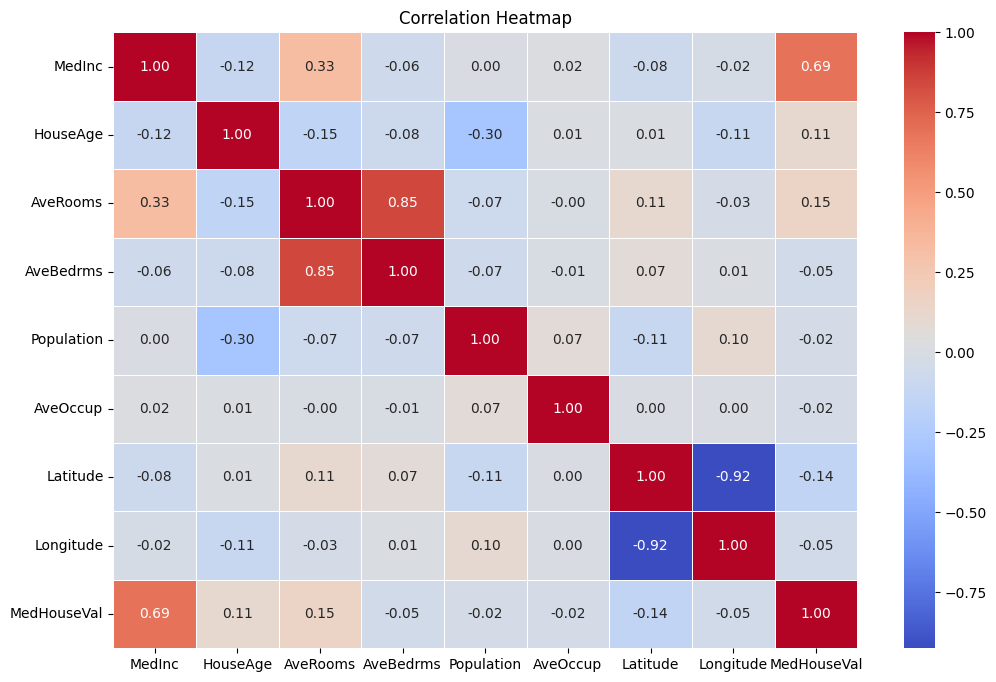

In [7]:
# Calculate correlations between all numerical features
correlation_matrix = df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

In [8]:
# Separate features and target variable

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


In [9]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (16512, 8)
Testing features: (4128, 8)
Training target: (16512,)
Testing target: (4128,)


In [10]:
from sklearn.linear_model import LinearRegression

# Create the baseline model
baseline_model = LinearRegression()

# Train the model
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully!")

Baseline model trained successfully!


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Make predictions on test data
y_pred = baseline_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

MAE  : 0.5332
RMSE : 0.7456
R²   : 0.5758


In [12]:
from sklearn.tree import DecisionTreeRegressor

# Create Decision Tree model
tree_model = DecisionTreeRegressor(
    random_state=42
)

# Train the model
tree_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [13]:
# Make predictions using Decision Tree
tree_pred = tree_model.predict(X_test)

# Calculate evaluation metrics
tree_mae = mean_absolute_error(y_test, tree_pred)
tree_rmse = np.sqrt(mean_squared_error(y_test, tree_pred))
tree_r2 = r2_score(y_test, tree_pred)

print(f"Decision Tree MAE  : {tree_mae:.4f}")
print(f"Decision Tree RMSE : {tree_rmse:.4f}")
print(f"Decision Tree R²   : {tree_r2:.4f}")

Decision Tree MAE  : 0.4558
Decision Tree RMSE : 0.7069
Decision Tree R²   : 0.6187


In [14]:
from sklearn.ensemble import RandomForestRegressor

# Create Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [15]:
# Make predictions using Random Forest
rf_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f"Random Forest MAE  : {rf_mae:.4f}")
print(f"Random Forest RMSE : {rf_rmse:.4f}")
print(f"Random Forest R²   : {rf_r2:.4f}")

Random Forest MAE  : 0.3276
Random Forest RMSE : 0.5057
Random Forest R²   : 0.8049


In [16]:
# Store model performance
model_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mae,
        tree_mae,
        rf_mae
    ],
    "RMSE": [
        rmse,
        tree_rmse,
        rf_rmse
    ],
    "R2": [
        r2,
        tree_r2,
        rf_r2
    ]
})

model_results

,Model,MAE,RMSE,R2
0,Linear Regression,0.533200,0.745581,0.575788
1,Decision Tree,0.455762,0.706900,0.618663
2,Random Forest,0.327599,0.505694,0.804850


In [17]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,MedInc,0.525037
5,AveOccup,0.138564
6,Latitude,0.088855
7,Longitude,0.088669
1,HouseAge,0.054558
2,AveRooms,0.044195
4,Population,0.030503
3,AveBedrms,0.029620


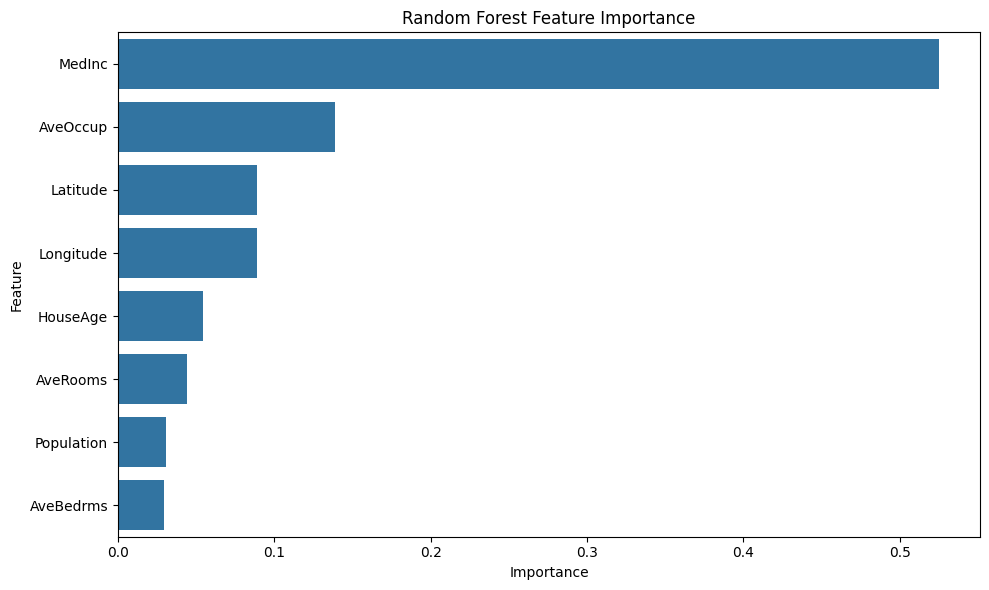

In [18]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

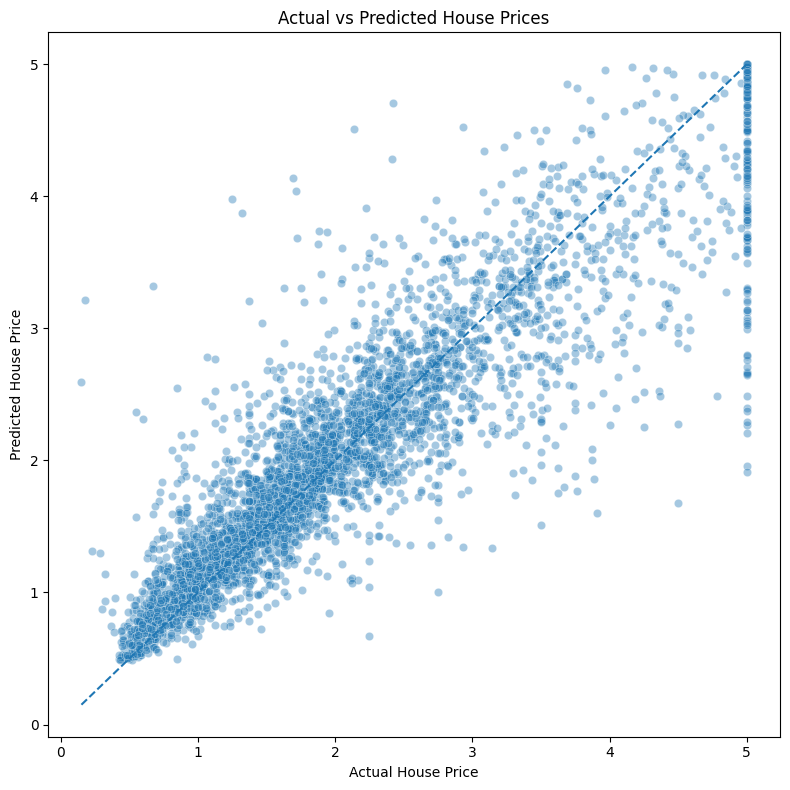

In [19]:
plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=rf_pred,
    alpha=0.4
)

# Perfect prediction line
min_value = min(y_test.min(), rf_pred.min())
max_value = max(y_test.max(), rf_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted House Prices")
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.tight_layout()
plt.show()

In [20]:
from sklearn.model_selection import GridSearchCV

# Define parameter combinations
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5]
}

# Create base Random Forest
rf_base = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

# Grid Search with 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

# Start tuning
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [21]:
# Get the best model found by GridSearchCV
tuned_rf_model = grid_search.best_estimator_

print("Tuned Random Forest model ready!")

Tuned Random Forest model ready!


In [22]:
# Predictions from the tuned Random Forest
tuned_pred = tuned_rf_model.predict(X_test)

# Calculate evaluation metrics
tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print(f"Tuned Random Forest MAE  : {tuned_mae:.4f}")
print(f"Tuned Random Forest RMSE : {tuned_rmse:.4f}")
print(f"Tuned Random Forest R²   : {tuned_r2:.4f}")

Tuned Random Forest MAE  : 0.3266
Tuned Random Forest RMSE : 0.5039
Tuned Random Forest R²   : 0.8062


In [23]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation using RMSE
cv_scores = cross_val_score(
    tuned_rf_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

cv_rmse = -cv_scores

print("Cross-Validation RMSE Scores:")
print(cv_rmse)

print(f"\nMean CV RMSE : {cv_rmse.mean():.4f}")
print(f"Std CV RMSE  : {cv_rmse.std():.4f}")

Cross-Validation RMSE Scores:
[0.51306686 0.5160572  0.50541956 0.50319402 0.51394659]

Mean CV RMSE : 0.5103
Std CV RMSE  : 0.0051


In [24]:
import joblib

# Save the trained model
model_path = "../models/house_price_model.pkl"

joblib.dump(tuned_rf_model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: ../models/house_price_model.pkl


In [25]:
import joblib

# Store model and feature information together
model_bundle = {
    "model": tuned_rf_model,
    "features": list(X.columns)
}

# Save the complete model bundle
joblib.dump(
    model_bundle,
    "../models/house_price_model.pkl"
)

print("Model bundle saved successfully!")
print("Features:", model_bundle["features"])

Model bundle saved successfully!
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [26]:
import joblib

# Load the saved model bundle
loaded_bundle = joblib.load("../models/house_price_model.pkl")

loaded_model = loaded_bundle["model"]
feature_names = loaded_bundle["features"]

print("Model loaded successfully!")
print("Features:", feature_names)

Model loaded successfully!
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [27]:
# Take one real house from the test dataset
sample_house = X_test.iloc[[0]]

# Predict its house value
sample_prediction = loaded_model.predict(sample_house)[0]

print("Predicted House Value:")
print(f"${sample_prediction * 100000:,.2f}")

Predicted House Value:
$49,446.50


In [28]:
# Get the actual house value
actual_value = y_test.iloc[0] * 100000

# Convert predicted value to dollars
predicted_value = sample_prediction * 100000

print(f"Actual House Value    : ${actual_value:,.2f}")
print(f"Predicted House Value : ${predicted_value:,.2f}")

error = abs(actual_value - predicted_value)

print(f"Absolute Error        : ${error:,.2f}")

Actual House Value    : $47,700.00
Predicted House Value : $49,446.50
Absolute Error        : $1,746.50


In [29]:
# Update the saved model bundle with model performance metrics

model_bundle = {
    "model": tuned_rf_model,
    "features": list(X.columns),
    "metrics": {
        "mae": tuned_mae,
        "rmse": tuned_rmse,
        "r2": tuned_r2,
        "cv_rmse": cv_rmse.mean()
    }
}

joblib.dump(
    model_bundle,
    "../models/house_price_model.pkl"
)

print("Model bundle updated successfully!")
print("\nModel Performance:")
print(f"MAE      : {tuned_mae:.4f}")
print(f"RMSE     : {tuned_rmse:.4f}")
print(f"R²       : {tuned_r2:.4f}")
print(f"CV RMSE  : {cv_rmse.mean():.4f}")

Model bundle updated successfully!

Model Performance:
MAE      : 0.3266
RMSE     : 0.5039
R²       : 0.8062
CV RMSE  : 0.5103
